# LSTM K-Fold Hyperparameter Search
### Anaerobic Digestion of Olive Mill Waste - Crete Case Study

---

## results from LSTM 1st training run

the LSTM 1st training run produced results that improve on both the RNN and
the ANN across all training metrics

**loss comparison across all 3 models:**

| model | final training Loss | converged |
|-------|-------------------|-----------|
| ANN (retrained) | 0.001549 | YES |
| RNN (first run) | 0.000138 | YES |
| LSTM (first run) | 0.000119 | YES |

the LSTM achieved a final loss 14% lower than the RNN and 92% lower than the
ANN. all 3 models converged. the LSTM loss drop in the last 50 epochs
was 0.00000232, below the 0.00005 convergence threshold

**R squared comparison:**

| output | ANN | RNN | LSTM | LSTM vs RNN |
|--------|-----|-----|------|-------------|
| dS/dt | 0.9982 | 0.9993 | 0.9994 | +0.0001 |
| dM/dt | 0.9984 | 0.9993 | 0.9994 | +0.0001 |
| dpH/dt | 0.9989 | 0.9977 | 0.9978 | +0.0001 |

the LSTM improved a little on the RNN across all 3 outputs. the improvements
are consistent, which is a sign that the gating mechanism
is having some benefit during training

**residual means:**

| output | RNN | LSTM |
|--------|-----|------|
| dS/dt | -0.000992 | 0.002701 |
| dM/dt | 0.000012 | 0.001219 |
| dpH/dt | 0.001881 | 0.001645 |

all residual means are close to 0. the LSTM shows a small positive bias in
dS/dt that was not present in the RNN, but the magnitude remains negligible
in standardised units

**important:**

training metrics alone do not predict offline performance. the RNN had excellent
training metrics but failed in the offline testing framework, producing MAPE of
24.02% for volatile solids and 17.19% for methane. the LSTM will only be
evaluated properly in the testing notebook. this K-Fold search optimises
hyperparameters for training loss, which is the best available proxy at this stage

---

## Purpose of this notebook

search for the best hyperparameters for the LSTM using K-Fold
cross validation across 6 folds. the search covers:

- hidden_dim: number of neurons in each LSTM layer
- learning rate
- batch size

the following are held constant:

- sequence length (seq_len = 12)
- number of LSTM layers (layer_dim = 2)
- number of folds (6)
- epochs per fold (100)


## 1. Imports and Setup

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import openpyxl
import copy
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold

torch.manual_seed(1)
np.random.seed(1)

print("imports ok")
print("torch version:", torch.__version__)

imports ok
torch version: 2.11.0


## 2. Load Data and Create Sequences

In [2]:
book = openpyxl.load_workbook('olive_mill_database.xlsx',
                               read_only=True, data_only=True)

sheet_ref = book['STANDARDISATION_REF']
data_ref  = []
for r in sheet_ref.iter_rows(min_row=4, values_only=True):
    data_ref.append([r[c] for c in range(8)])

print(f"loaded {len(data_ref)} rows from STANDARDISATION_REF")

loaded 1080 rows from STANDARDISATION_REF


In [3]:
scaler = StandardScaler()
scaler.fit(data_ref)
std_ref = scaler.transform(data_ref)

x_ref = std_ref[:, 0:5]
y_ref = std_ref[:, 5:8]

seq_len      = 12
n_runs       = 36
rows_per_run = 30

sequences_x = []
sequences_y = []

for run_i in range(n_runs):
    start = run_i * rows_per_run
    end   = start + rows_per_run
    run_x = x_ref[start:end]
    run_y = y_ref[start:end]
    for t in range(rows_per_run - seq_len):
        sequences_x.append(run_x[t : t + seq_len])
        sequences_y.append(run_y[t + seq_len - 1])

sequences_x = np.array(sequences_x)
sequences_y = np.array(sequences_y)

print(f"sequences shape: {sequences_x.shape}")
print(f"targets shape  : {sequences_y.shape}")

sequences shape: (648, 12, 5)
targets shape  : (648, 3)


## 3. Model Definition

In [4]:
class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, layer_dim, output_dim):
        super(LSTMModel, self).__init__()
        self.hidden_dim = hidden_dim
        self.layer_dim  = layer_dim
        self.lstm = nn.LSTM(input_dim, hidden_dim, layer_dim,
                            batch_first=True)
        self.fc   = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        h0  = torch.zeros(self.layer_dim, x.size(0), self.hidden_dim)
        c0  = torch.zeros(self.layer_dim, x.size(0), self.hidden_dim)
        out, (hn, cn) = self.lstm(x, (h0.detach(), c0.detach()))
        out = self.fc(out[:, -1, :])
        return out

print("LSTMModel class defined")

LSTMModel class defined


## 4. Search Grid

the grid is centred around hidden_dim=20 from the 1st run,
smaller batch sizes are included based on the RNN K-Fold finding
that batch=25 outperformed batch=50


In [5]:
hidden_values = [10, 15, 20, 25, 30]
lr_values     = [1e-3, 5e-4, 1e-4]
batch_values  = [25, 50, 100]

n_splits    = 6
fold_epochs = 100

total_combos = len(hidden_values) * len(lr_values) * len(batch_values)
print(f"hidden_dim values : {hidden_values}")
print(f"learning rates    : {lr_values}")
print(f"batch sizes       : {batch_values}")
print(f"folds             : {n_splits}")
print(f"epochs per fold   : {fold_epochs}")
print()
print(f"total combinations: {total_combos}")
print(f"total training runs: {total_combos * n_splits}")
print()
print("note: LSTM is slower than RNN per epoch due to additional gates")
print("expect this to take 5 to 10 minutes")

hidden_dim values : [10, 15, 20, 25, 30]
learning rates    : [0.001, 0.0005, 0.0001]
batch sizes       : [25, 50, 100]
folds             : 6
epochs per fold   : 100

total combinations: 45
total training runs: 270

note: LSTM is slower than RNN per epoch due to additional gates
expect this to take 5 to 10 minutes


## 5. Run the Grid Search

In [6]:
kfold  = KFold(n_splits=n_splits, shuffle=True, random_state=1)
splits = list(kfold.split(sequences_x))

results     = []
combo_count = 0

for hidden_dim in hidden_values:
    for lr in lr_values:
        for batch_size in batch_values:

            combo_count += 1

            model     = LSTMModel(5, hidden_dim, 2, 3)
            loss_fn   = nn.MSELoss(reduction='mean')
            optimizer = torch.optim.Adam(model.parameters(), lr=lr)

            init_weights = copy.deepcopy(model.state_dict())
            init_optim   = copy.deepcopy(optimizer.state_dict())

            fold_losses = []

            for fold_i, (train_idx, val_idx) in enumerate(splits):

                model.load_state_dict(init_weights)
                optimizer.load_state_dict(init_optim)
                model.train()

                x_tr = torch.tensor(sequences_x[train_idx], dtype=torch.float32)
                y_tr = torch.tensor(sequences_y[train_idx], dtype=torch.float32)
                x_vl = torch.tensor(sequences_x[val_idx],   dtype=torch.float32)
                y_vl = torch.tensor(sequences_y[val_idx],   dtype=torch.float32)

                fold_dataset = torch.utils.data.TensorDataset(x_tr, y_tr)
                fold_loader  = torch.utils.data.DataLoader(
                    fold_dataset, batch_size=batch_size, shuffle=True)

                for epoch in range(fold_epochs):
                    for x_batch, y_batch in fold_loader:
                        y_pred = model(x_batch)
                        loss   = loss_fn(y_pred, y_batch)
                        optimizer.zero_grad()
                        loss.backward()
                        optimizer.step()

                model.eval()
                with torch.no_grad():
                    val_pred = model(x_vl)
                    val_loss = loss_fn(val_pred, y_vl).item()
                fold_losses.append(val_loss)

            avg_loss = np.mean(fold_losses)
            std_loss = np.std(fold_losses)

            results.append({
                'hidden_dim': hidden_dim, 'lr': lr, 'batch': batch_size,
                'avg_val_loss': avg_loss,
                'std_val_loss': std_loss,
                'fold_losses':  fold_losses,
            })

            if combo_count % 5 == 0 or combo_count == total_combos:
                print(f"[{combo_count:>2}/{total_combos}]  "
                      f"hidden={hidden_dim:>2} lr={lr:.0e} batch={batch_size:>3}  "
                      f"avg_val_loss={avg_loss:.6f}  std={std_loss:.6f}")

print()
print(f"grid search complete. {len(results)} combinations evaluated.")

[ 5/45]  hidden=10 lr=5e-04 batch= 50  avg_val_loss=0.001098  std=0.000495
[10/45]  hidden=15 lr=1e-03 batch= 25  avg_val_loss=0.000057  std=0.000013
[15/45]  hidden=15 lr=5e-04 batch=100  avg_val_loss=0.001594  std=0.000502
[20/45]  hidden=20 lr=1e-03 batch= 50  avg_val_loss=0.000057  std=0.000020
[25/45]  hidden=20 lr=1e-04 batch= 25  avg_val_loss=0.001545  std=0.000637
[30/45]  hidden=25 lr=1e-03 batch=100  avg_val_loss=0.000159  std=0.000047
[35/45]  hidden=25 lr=1e-04 batch= 50  avg_val_loss=0.003049  std=0.000861
[40/45]  hidden=30 lr=5e-04 batch= 25  avg_val_loss=0.000038  std=0.000010
[45/45]  hidden=30 lr=1e-04 batch=100  avg_val_loss=0.011688  std=0.003930

grid search complete. 45 combinations evaluated.


## 6. Results — Top 10 Combinations

In [12]:
results_sorted = sorted(results, key=lambda x: x['avg_val_loss'])

print("TOP 10 COMBINATIONS:")
print("-" * 65)
print(f"{'rank':>4} {'hidden':>7} {'LR':>8} {'batch':>6} "
      f"{'avg val loss':>14} {'std':>10}")
print("-" * 65)

for i, r in enumerate(results_sorted[:10], 1):
    print(f"{i:>4} {r['hidden_dim']:>7} {r['lr']:>8.0e} {r['batch']:>6} "
          f"{r['avg_val_loss']:>14.6f} {r['std_val_loss']:>10.6f}")

print("-" * 65)
best = results_sorted[0]
print(f"BEST: hidden_dim={best['hidden_dim']}, "
      f"lr={best['lr']:.0e}, batch={best['batch']}")
print(f"      avg val loss={best['avg_val_loss']:.6f}  "
      f"std={best['std_val_loss']:.6f}")

TOP 10 COMBINATIONS:
-----------------------------------------------------------------
rank  hidden       LR  batch   avg val loss        std
-----------------------------------------------------------------
   1      30    1e-03     25       0.000031   0.000007
   2      20    1e-03     25       0.000033   0.000014
   3      25    1e-03     25       0.000037   0.000014
   4      30    5e-04     25       0.000038   0.000010
   5      30    1e-03     50       0.000039   0.000011
   6      25    1e-03     50       0.000044   0.000013
   7      15    1e-03     25       0.000057   0.000013
   8      20    1e-03     50       0.000057   0.000020
   9      25    5e-04     25       0.000066   0.000017
  10      30    1e-03    100       0.000067   0.000013
-----------------------------------------------------------------
BEST: hidden_dim=30, lr=1e-03, batch=25
      avg val loss=0.000031  std=0.000007


## 7. Visualise Results

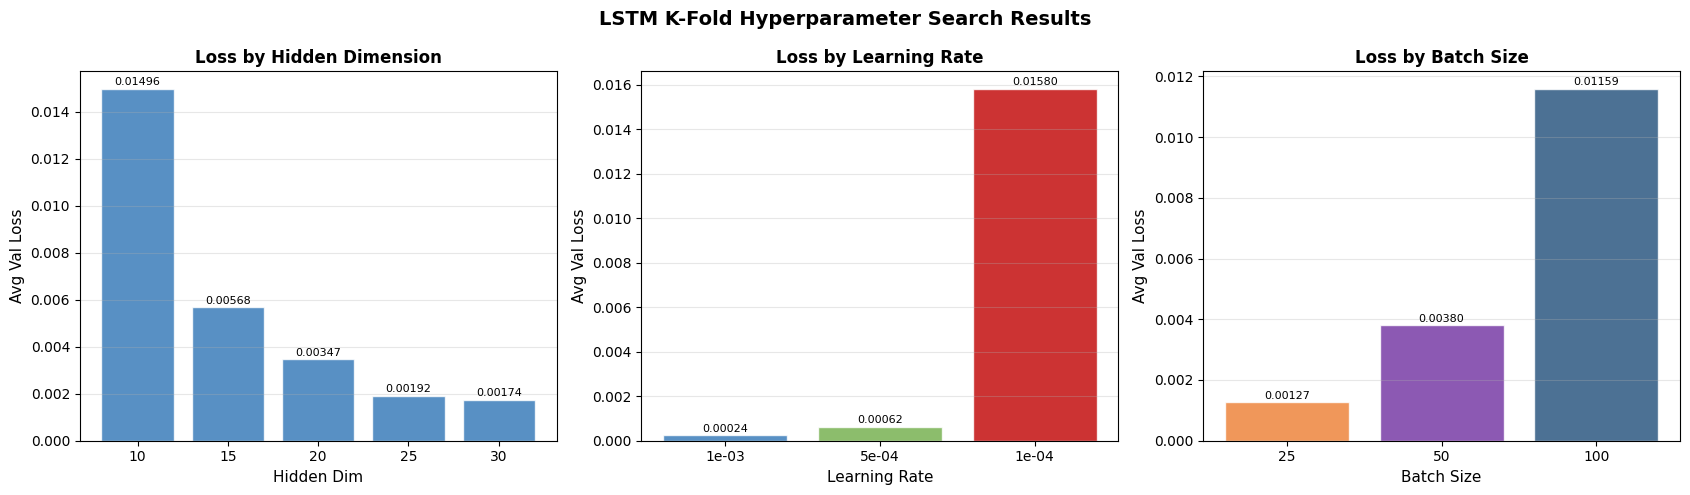

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

hid_means = []
for h in hidden_values:
    vals = [r['avg_val_loss'] for r in results if r['hidden_dim'] == h]
    hid_means.append(np.mean(vals))

axes[0].bar([str(h) for h in hidden_values], hid_means,
            color='#2E75B6', alpha=0.8, edgecolor='white')
axes[0].set_xlabel('Hidden Dim', fontsize=11)
axes[0].set_ylabel('Avg Val Loss', fontsize=11)
axes[0].set_title('Loss by Hidden Dimension', fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(hid_means):
    axes[0].text(i, v + max(hid_means)*0.01, f'{v:.5f}',
                 ha='center', fontsize=8)

lr_means = []
for lr in lr_values:
    vals = [r['avg_val_loss'] for r in results if r['lr'] == lr]
    lr_means.append(np.mean(vals))
axes[1].bar([f'{lr:.0e}' for lr in lr_values], lr_means,
            color=['#2E75B6','#70AD47','#C00000'], alpha=0.8, edgecolor='white')
axes[1].set_xlabel('Learning Rate', fontsize=11)
axes[1].set_ylabel('Avg Val Loss', fontsize=11)
axes[1].set_title('Loss by Learning Rate', fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(lr_means):
    axes[1].text(i, v + max(lr_means)*0.01, f'{v:.5f}',
                 ha='center', fontsize=8)

batch_means = []
for b in batch_values:
    vals = [r['avg_val_loss'] for r in results if r['batch'] == b]
    batch_means.append(np.mean(vals))
axes[2].bar([str(b) for b in batch_values], batch_means,
            color=['#ED7D31','#7030A0','#1F4E79'], alpha=0.8, edgecolor='white')
axes[2].set_xlabel('Batch Size', fontsize=11)
axes[2].set_ylabel('Avg Val Loss', fontsize=11)
axes[2].set_title('Loss by Batch Size', fontweight='bold')
axes[2].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(batch_means):
    axes[2].text(i, v + max(batch_means)*0.01, f'{v:.5f}',
                 ha='center', fontsize=8)

plt.suptitle('LSTM K-Fold Hyperparameter Search Results',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

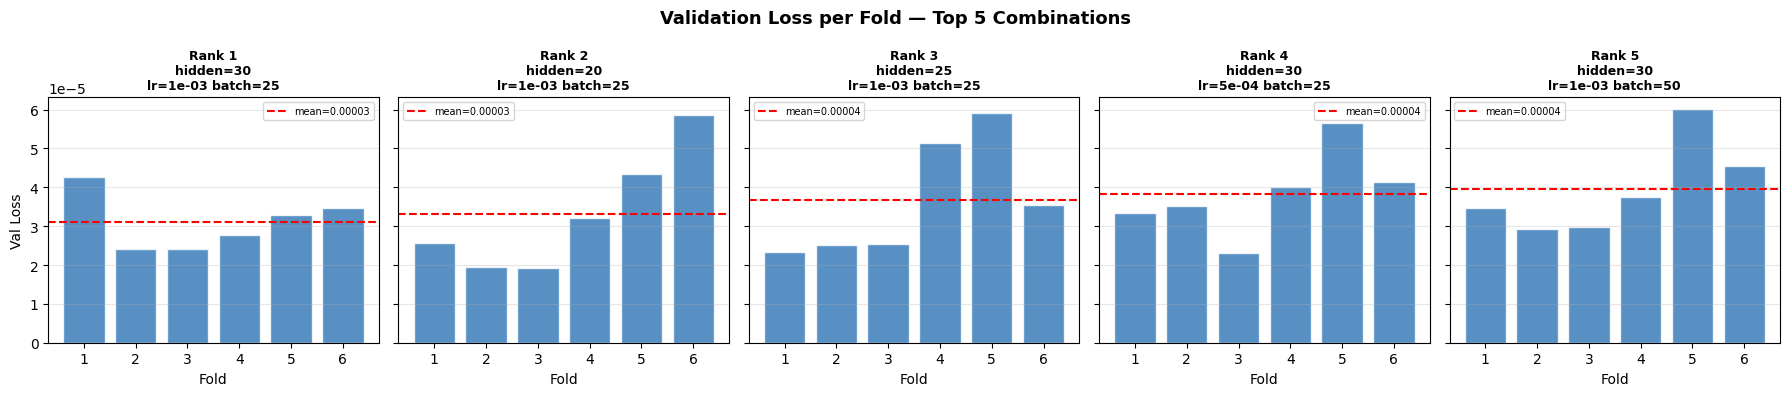

consistent bars across folds indicate stable generalisation


In [14]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharey=True)

for ax, r, rank in zip(axes, results_sorted[:5], range(1, 6)):
    ax.bar(range(1, n_splits+1), r['fold_losses'],
           color='#2E75B6', alpha=0.8, edgecolor='white')
    ax.axhline(r['avg_val_loss'], color='red', linestyle='--',
               linewidth=1.5, label=f"mean={r['avg_val_loss']:.5f}")
    ax.set_title(f"Rank {rank}\nhidden={r['hidden_dim']}\n"
                 f"lr={r['lr']:.0e} batch={r['batch']}",
                 fontsize=9, fontweight='bold')
    ax.set_xlabel('Fold')
    if rank == 1:
        ax.set_ylabel('Val Loss')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Validation Loss per Fold — Top 5 Combinations',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print("consistent bars across folds indicate stable generalisation")

## 8. Best Hyperparameters

In [15]:
best = results_sorted[0]

print("=" * 55)
print("BEST HYPERPARAMETERS FROM LSTM K-FOLD SEARCH")
print("=" * 55)
print(f"  hidden_dim    : {best['hidden_dim']}")
print(f"  learning rate : {best['lr']}")
print(f"  batch size    : {best['batch']}")
print(f"  avg val loss  : {best['avg_val_loss']:.6f}")
print(f"  std val loss  : {best['std_val_loss']:.6f}")
print("=" * 55)
print()
print("comparison to first training run:")
print(f"  first run : hidden_dim=20, lr=1e-3, batch=50")
print(f"  best found: hidden_dim={best['hidden_dim']}, "
      f"lr={best['lr']:.0e}, batch={best['batch']}")
print()
print("WORST 5 COMBINATIONS:")
print("-" * 55)
for r in results_sorted[-5:]:
    print(f"  hidden={r['hidden_dim']:>2} lr={r['lr']:.0e} "
          f"batch={r['batch']:>3}  avg_val_loss={r['avg_val_loss']:.6f}")

BEST HYPERPARAMETERS FROM LSTM K-FOLD SEARCH
  hidden_dim    : 30
  learning rate : 0.001
  batch size    : 25
  avg val loss  : 0.000031
  std val loss  : 0.000007

comparison to first training run:
  first run : hidden_dim=20, lr=1e-3, batch=50
  best found: hidden_dim=30, lr=1e-03, batch=25

WORST 5 COMBINATIONS:
-------------------------------------------------------
  hidden=25 lr=1e-04 batch=100  avg_val_loss=0.012322
  hidden=20 lr=1e-04 batch=100  avg_val_loss=0.022479
  hidden=10 lr=1e-04 batch= 50  avg_val_loss=0.032038
  hidden=15 lr=1e-04 batch=100  avg_val_loss=0.033497
  hidden=10 lr=1e-04 batch=100  avg_val_loss=0.084487


## 9. Save Results

In [16]:
import json

save_data = []
for r in results_sorted:
    save_data.append({
        'hidden_dim'   : r['hidden_dim'],
        'lr'           : r['lr'],
        'batch'        : r['batch'],
        'avg_val_loss' : r['avg_val_loss'],
        'std_val_loss' : r['std_val_loss'],
        'fold_losses'  : r['fold_losses'],
    })

with open('kfold_results_LSTM.json', 'w') as f:
    json.dump(save_data, f, indent=2)

print("results saved to kfold_results_LSTM.json")
print()
print("next step: LSTM_Retrain_Olive_Mill.ipynb")
print(f"  hidden_dim = {best['hidden_dim']}")
print(f"  lr         = {best['lr']:.0e}")
print(f"  batch      = {best['batch']}")
print(f"  layer_dim  = 2  (unchanged)")
print(f"  epochs     = 300")

# results extractor
print()
print("=" * 60)
print("RESULTS EXTRACTOR")
print("=" * 60)
print(f"K-Fold best combination:")
print(f"  hidden_dim : {best['hidden_dim']}")
print(f"  lr         : {best['lr']:.0e}")
print(f"  batch      : {best['batch']}")
print(f"  avg loss   : {best['avg_val_loss']:.6f}")
print(f"  std loss   : {best['std_val_loss']:.6f}")
print(f"  fold losses: {[round(f,6) for f in best['fold_losses']]}")

results saved to kfold_results_LSTM.json

next step: LSTM_Retrain_Olive_Mill.ipynb
  hidden_dim = 30
  lr         = 1e-03
  batch      = 25
  layer_dim  = 2  (unchanged)
  epochs     = 300

RESULTS EXTRACTOR
K-Fold best combination:
  hidden_dim : 30
  lr         : 1e-03
  batch      : 25
  avg loss   : 0.000031
  std loss   : 0.000007
  fold losses: [4.3e-05, 2.4e-05, 2.4e-05, 2.8e-05, 3.3e-05, 3.5e-05]
